# Prédiction SiteEnergyUse(kBtu)

In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import math

In [3]:
from sklearn.model_selection import train_test_split
from datetime import datetime

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet

from sklearn.ensemble import RandomForestRegressor

In [4]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [5]:
ls -lh ./data

total 1,4M
-rw-r--r-- 1 mijka mijka 1,2M  7 nov.  09:53 2016_Building_Energy_Benchmarking.csv
-rw-r--r-- 1 mijka mijka 143K  7 nov.  15:09 clean_seattle_buildings.csv


In [6]:
path = './data/'
filename = 'clean_seattle_buildings.csv'
csv_path = path + filename
df = pd.read_csv(csv_path, on_bad_lines='skip', low_memory=False)

In [7]:
df.head()

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Shops / Services,No UseType,No UseType,60.0,7226362.5,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Shops / Services,Parking,Shops / Services,61.0,8387933.0,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Shops / Services,No UseType,No UseType,43.0,72587024.0,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Shops / Services,No UseType,No UseType,56.0,6794584.0,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Shops / Services,Parking,Shops / Services,75.0,14172606.0,505.01


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1030 non-null   object 
 1   PrimaryPropertyType           1030 non-null   object 
 2   ZipCode                       1030 non-null   float64
 3   Neighborhood                  1030 non-null   object 
 4   YearBuilt                     1030 non-null   int64  
 5   NumberofBuildings             1030 non-null   float64
 6   NumberofFloors                1030 non-null   int64  
 7   PropertyGFATotal              1030 non-null   int64  
 8   PropertyGFAParking            1030 non-null   int64  
 9   PropertyGFABuilding(s)        1030 non-null   int64  
 10  LargestPropertyUseType        1030 non-null   object 
 11  SecondLargestPropertyUseType  1030 non-null   object 
 12  ThirdLargestPropertyUseType   1030 non-null   object 
 13  ENE

In [9]:
df.dtypes

BuildingType                     object
PrimaryPropertyType              object
ZipCode                         float64
Neighborhood                     object
YearBuilt                         int64
NumberofBuildings               float64
NumberofFloors                    int64
PropertyGFATotal                  int64
PropertyGFAParking                int64
PropertyGFABuilding(s)            int64
LargestPropertyUseType           object
SecondLargestPropertyUseType     object
ThirdLargestPropertyUseType      object
ENERGYSTARScore                 float64
SiteEnergyUse(kBtu)             float64
TotalGHGEmissions               float64
dtype: object

In [10]:
df.shape

(1030, 16)

In [11]:
df.isna().sum()

BuildingType                    0
PrimaryPropertyType             0
ZipCode                         0
Neighborhood                    0
YearBuilt                       0
NumberofBuildings               0
NumberofFloors                  0
PropertyGFATotal                0
PropertyGFAParking              0
PropertyGFABuilding(s)          0
LargestPropertyUseType          0
SecondLargestPropertyUseType    0
ThirdLargestPropertyUseType     0
ENERGYSTARScore                 0
SiteEnergyUse(kBtu)             0
TotalGHGEmissions               0
dtype: int64

In [12]:
#save separately energy star score
energy_star_score = df['ENERGYSTARScore']
df.drop('ENERGYSTARScore', axis=1, inplace=True)
df.shape

(1030, 15)

In [13]:
df_cols = df.columns.tolist()
col_to_check = 'ENERGYSTARScore'

if  (col_to_check in df_cols):
    star_score_status = True
else:
    star_score_status = False
print(star_score_status)

False


In [14]:
#df.isna().sum().sum()

# Prep Vectors & Matrices

In [15]:
y = df.copy()[{'SiteEnergyUse(kBtu)', 'TotalGHGEmissions'}]
X = df.copy().drop(['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'], axis=1)

label = 'SiteEnergyUse(kBtu)' # change label if needed

## Normalisation & One Hot Encoder

### isoler var num et var cat

In [16]:
categorical_columns = X.select_dtypes(['category','object']).columns
numerical_columns = X.select_dtypes(['int32','float64']).columns

In [17]:
categorical_columns

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType'],
      dtype='object')

In [18]:
numerical_columns

Index(['ZipCode', 'NumberofBuildings'], dtype='object')

In [19]:
df.describe()

,ZipCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),TotalGHGEmissions
count,1030.000000,1030.000000,1030.000000,1030.000000,1.030000e+03,1030.000000,1.030000e+03,1.030000e+03,1030.000000
mean,98116.429126,1963.275728,1.044660,4.891262,1.249758e+05,15367.257282,1.096086e+05,8.420069e+06,184.649243
std,17.471407,31.591103,0.480874,7.952716,2.031869e+05,46348.066938,1.766832e+05,2.536558e+07,845.850913
min,98020.000000,1900.000000,1.000000,0.000000,1.630000e+04,0.000000,1.620000e+04,7.971180e+04,-0.800000
25%,98104.000000,1938.000000,1.000000,1.000000,3.247275e+04,0.000000,3.134650e+04,1.292208e+06,20.645000
50%,98109.000000,1967.000000,1.000000,3.000000,5.392750e+04,0.000000,5.113400e+04,2.617168e+06,49.270000
75%,98122.000000,1988.750000,1.000000,5.000000,1.237052e+05,0.000000,1.060845e+05,7.183862e+06,130.947500
max,98199.000000,2015.000000,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,4.483853e+08,16870.980000


In [20]:
df[categorical_columns].describe()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
count,1030,1030,1030,1030,1030,1030
unique,4,14,13,9,8,9
top,NonResidential,Small- and Mid-Sized Office,DOWNTOWN,Industry / Offices,No UseType,No UseType
freq,936,236,240,599,558,886


In [21]:
df[categorical_columns].dtypes

BuildingType                    object
PrimaryPropertyType             object
Neighborhood                    object
LargestPropertyUseType          object
SecondLargestPropertyUseType    object
ThirdLargestPropertyUseType     object
dtype: object

### Normalisation num cats

In [22]:
ss = StandardScaler()

In [23]:
### normaliser num
X[numerical_columns] = ss.fit_transform(X[numerical_columns])

### Encoding

#### Check categorical features

In [24]:
X.shape

(1030, 13)

In [25]:
X.select_dtypes(['category','object']).nunique()

BuildingType                     4
PrimaryPropertyType             14
Neighborhood                    13
LargestPropertyUseType           9
SecondLargestPropertyUseType     8
ThirdLargestPropertyUseType      9
dtype: int64

In [26]:
X.select_dtypes(['category','object']).head()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,NonResidential,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
1,NonResidential,Hotel,DOWNTOWN,Shops / Services,Parking,Shops / Services
2,NonResidential,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
3,NonResidential,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
4,NonResidential,Hotel,DOWNTOWN,Shops / Services,Parking,Shops / Services


In [27]:
df['LargestPropertyUseType'].unique()

array(['Shops / Services', 'Public Services', 'Education Facility',
       'Industry / Offices', 'health_facilities',
       'Social / Entertainement', 'Parking', 'Other', 'No UseType'],
      dtype=object)

**Encoding strategy :**

=> BuildingType => OHE

=> other features => OrdinalEncoder

In [28]:
ohe_features = ['BuildingType']
ord_features = X.drop(['BuildingType'], axis=1).select_dtypes(['category','object']).columns.to_list()

In [29]:
ohe = OneHotEncoder(sparse=False)
ord = OrdinalEncoder()

#### OHE

In [30]:
X[ohe_features].head()

,BuildingType
0,NonResidential
1,NonResidential
2,NonResidential
3,NonResidential
4,NonResidential


In [31]:
X[ohe_features].shape

(1030, 1)

In [32]:
multiple_ohe = ohe.fit_transform(X[ohe_features])
ohe_df = pd.DataFrame(multiple_ohe, columns=ohe.get_feature_names())

In [33]:
ohe_df

,x0_Campus,x0_NonResidential,x0_Nonresidential COS,x0_SPS-District K-12
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
1025,0.0,0.0,1.0,0.0
1026,0.0,1.0,0.0,0.0
1027,0.0,1.0,0.0,0.0
1028,0.0,1.0,0.0,0.0


#### OrdinalEncoder

In [34]:
X[ord_features].head()

,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
1,Hotel,DOWNTOWN,Shops / Services,Parking,Shops / Services
2,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
3,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
4,Hotel,DOWNTOWN,Shops / Services,Parking,Shops / Services


In [35]:
X[ord_features].shape

(1030, 5)

In [36]:
multiple_ord = ord.fit_transform(X[ord_features])
ord_df = pd.DataFrame(multiple_ord, columns=ord_features)

In [37]:
ord_df

,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,2.0,3.0,6.0,2.0,2.0
1,2.0,3.0,6.0,4.0,6.0
2,2.0,3.0,6.0,2.0,2.0
3,2.0,3.0,6.0,2.0,2.0
4,2.0,3.0,6.0,4.0,6.0
...,...,...,...,...,...
1025,4.0,6.0,1.0,4.0,6.0
1026,2.0,6.0,6.0,4.0,6.0
1027,12.0,5.0,1.0,2.0,2.0
1028,10.0,5.0,1.0,2.0,2.0


#### Merge encoded features

In [38]:
X_num = X.drop(columns=categorical_columns)

In [39]:
X_enc = pd.concat([ohe_df, ord_df, X_num],axis=1)

In [40]:
X_enc

,x0_Campus,x0_NonResidential,x0_Nonresidential COS,x0_SPS-District K-12,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ZipCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s)
0,0.0,1.0,0.0,0.0,2.0,3.0,6.0,2.0,2.0,-0.883536,1927,-0.092918,12,88434,0,88434
1,0.0,1.0,0.0,0.0,2.0,3.0,6.0,4.0,6.0,-0.883536,1996,-0.092918,11,103566,15064,88502
2,0.0,1.0,0.0,0.0,2.0,3.0,6.0,2.0,2.0,-0.883536,1969,-0.092918,41,956110,196718,759392
3,0.0,1.0,0.0,0.0,2.0,3.0,6.0,2.0,2.0,-0.883536,1926,-0.092918,10,61320,0,61320
4,0.0,1.0,0.0,0.0,2.0,3.0,6.0,4.0,6.0,0.261747,1980,-0.092918,18,175580,62000,113580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,0.0,0.0,1.0,0.0,4.0,6.0,1.0,4.0,6.0,-0.425423,2014,-0.092918,13,536697,197659,339038
1026,0.0,1.0,0.0,0.0,2.0,6.0,6.0,4.0,6.0,-0.769008,2014,-0.092918,4,126823,41539,85284
1027,0.0,1.0,0.0,0.0,12.0,5.0,1.0,2.0,2.0,-0.482687,1955,-0.092918,1,52085,4222,47863
1028,0.0,1.0,0.0,0.0,10.0,5.0,1.0,2.0,2.0,-0.482687,1929,-0.092918,2,24990,0,24990


In [41]:
X.shape

(1030, 13)

In [42]:
X_enc.shape

(1030, 16)

# Modélisation

## train_test_split

In [43]:
X_enc.shape

(1030, 16)

In [44]:
y[label].shape

(1030,)

In [45]:
X_train, X_test, y_train, y_test = \
            train_test_split(X_enc, 
                             y[label],  ## label / current single target
                             test_size = 0.2, 
                             random_state = 42
                            )

In [46]:
X_train.shape

(824, 16)

In [47]:
X_test.shape

(206, 16)

In [48]:
y_train.shape

(824,)

In [49]:
y_test.shape

(206,)

## Results Dataframe

In [50]:
results = pd.DataFrame({})

In [51]:
# check label
label

'SiteEnergyUse(kBtu)'

Empty models perfs dataframe

In [52]:
models_perfs = pd.DataFrame({'Label': pd.Series(dtype='str'),
                           'Model': pd.Series(dtype='str'),
                           'Star Score': pd.Series(dtype='bool'),
                           'Duration seconds': pd.Series(dtype='object'),
                           'MAE': pd.Series(dtype='float'),
                           'RMSE': pd.Series(dtype='float'),
                           'R2': pd.Series(dtype='float')
                            })

scorings : https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

multiple scorings : https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html

## Linear Regressor

In [53]:
model = LinearRegression()

start_time = datetime.now()

cv_results = cross_validate(model, X_train, y_train, cv=10)

end_time = datetime.now()
total_time_spent = end_time - start_time
total_time_spent
total_seconds_spent = total_time_spent.total_seconds()

In [54]:
base_model_score = cv_results['test_score'].mean()
base_model_score

0.046542371009985414

In [55]:
scores = cross_val_score(model, X_train, y_train, cv = 10)    #cv is the number of folds

In [56]:
print(scores)
print(np.mean(scores))
print(np.std(scores))

[ 0.24177921  0.52000538  0.40737514  0.06255025  0.23285057  0.88194987
 -2.84573134  0.72431103  0.1672165   0.0731171 ]
0.046542371009985414
0.99826066968776


In [57]:
X_train.shape

(824, 16)

In [58]:
X_test.shape

(206, 16)

In [59]:
model_name = type(model).__name__

model.fit(X_train, y_train)
predictions = model.predict(X_test)


MAE = mean_absolute_error(y_test, predictions)
RMSE = math.sqrt(mean_squared_error(y_test, predictions))
R2 = r2_score(y_test, predictions)

In [60]:
predictions.shape

(206,)

In [61]:
print(model_name)
print("    MAE :  ", MAE)
print("    RMSE : ", RMSE)
print("    R2 :   ", R2)

LinearRegression
    MAE :   5973444.818814505
    RMSE :  19635006.359702766
    R2 :    0.26184196483276057


In [62]:
linear_infos = {'Label': label, 
                'Model': model_name, 
                'Star Score': star_score_status,
                'Duration seconds': total_seconds_spent, 
                'MAE': MAE, 
                'RMSE': RMSE, 
                'R2': R2}
models_perfs = models_perfs.append(linear_infos, ignore_index=True)

In [63]:
models_perfs

,Label,Model,Star Score,Duration seconds,MAE,RMSE,R2
0,SiteEnergyUse(kBtu),LinearRegression,False,0.150367,5.973445e+06,1.963501e+07,0.261842


## ElasticNet

In [64]:
#rappel de la fonction de coût du elasticnet
#1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

model = ElasticNet()
parameters = {'tol' : [0.1,0.01,0.001,0.0001],
              "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  #alpha, coef qui multiplie le terme de pénalité)
              "l1_ratio": np.arange(0.0, 1.0, 0.1)}#L1 ratio , =1 équivaut à un Lasso, 0 à un Ridge

#scoring_list = {'MSE' : 'neg_mean_squared_error'}
scoring_list = {'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}

elastic_grid = GridSearchCV(estimator = model, 
                      param_grid = parameters,
                      scoring = 'r2',
                      #scoring = scoring_list,
                      #refit="RMSE",
                      cv=5,
                      verbose=0
                     )

start_time = datetime.now()
elastic_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                         'l1_ratio': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'tol': [0.1, 0.01, 0.001, 0.0001]},
             scoring='r2')

In [65]:
## favoriser R2, refaire GSCV

In [66]:
end_time = datetime.now()
total_time_spent = end_time - start_time
total_seconds_spent = total_time_spent.total_seconds()

In [67]:
results = elastic_grid.cv_results_

In [68]:
results.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_alpha', 'param_l1_ratio', 'param_tol', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [69]:
en_best = elastic_grid.best_estimator_
en_best

ElasticNet(alpha=0.1, l1_ratio=0.2, tol=0.1)

In [70]:
#elastic_grid.best_params_

In [71]:
#elastic_grid.best_score_

In [72]:
#en_best.fit(X_train, y_train)
predictions = elastic_grid.predict(X_test)

model_name = type(model).__name__
EN_MAE = mean_absolute_error(y_test, predictions)
EN_RMSE = math.sqrt(mean_squared_error(y_test, predictions))
EN_R2 = r2_score(y_test, predictions)

In [73]:
print(model_name)
print("    MAE :  ", MAE)
print("    RMSE : ", RMSE)
print("    R2 :   ", R2)

ElasticNet
    MAE :   5973444.818814505
    RMSE :  19635006.359702766
    R2 :    0.26184196483276057


In [74]:
elasticnet_infos = {'Label': label, 
                'Model': model_name, 
                'Star Score': star_score_status,
                'Duration seconds': total_seconds_spent, 
                'MAE': MAE, 
                'RMSE': RMSE,
                'R2': R2}
models_perfs = models_perfs.append(elasticnet_infos, ignore_index=True)

In [75]:
models_perfs

,Label,Model,Star Score,Duration seconds,MAE,RMSE,R2
0,SiteEnergyUse(kBtu),LinearRegression,False,0.150367,5.973445e+06,1.963501e+07,0.261842
1,SiteEnergyUse(kBtu),ElasticNet,False,112.457782,5.973445e+06,1.963501e+07,0.261842


## Random Forest

In [76]:
parameters = {
    'n_estimators' : [10,50,100,300,500], #nombre d'arbres de décision
    'min_samples_leaf' : [1,3,5,10], #nombre de feuilles minimales dans un noeud
    'max_features': ['auto', 'sqrt'] #nombre de features observées pour chaque arbre
}

In [77]:
model = RandomForestRegressor()
rfr_search = GridSearchCV(model,
                            param_grid = parameters,
                            #scoring='mean_squared_error',
                            verbose=2,
                            cv=5)

start_time = datetime.now()
rfr_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.4s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.3s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.3s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.3s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.4s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=100; total time=   0.6s
[CV] END max_

[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   1.1s
[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   1.1s
[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   1.1s
[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   1.1s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=50; tot

[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=300; total time=   1.3s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=300; total time=   1.9s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   3.0s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   3.1s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   3.2s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   3.1s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   3.2s


GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 3, 5, 10],
                         'n_estimators': [10, 50, 100, 300, 500]},
             verbose=2)

In [78]:
end_time = datetime.now()
total_time_spent = end_time - start_time
total_seconds_spent = total_time_spent.total_seconds()

In [79]:
rfr_search.best_params_

{'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 50}

In [80]:
coefficients = abs(rfr_search.best_estimator_.feature_importances_)
liste_coefs_rer = pd.concat((pd.DataFrame(X.columns, columns = ['Variable']), 
                      pd.DataFrame(coefficients, columns = ['Coefficient'])), axis = 1).sort_values(by='Coefficient', ascending = False)

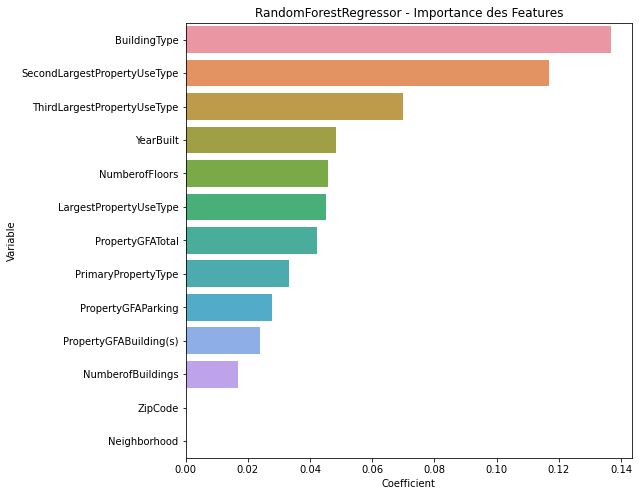

In [81]:
plt.figure(figsize=(8,8))
plt.title('RandomForestRegressor - Importance des Features')
sns.barplot(y = liste_coefs_rer['Variable'].head(20),
            x = liste_coefs_rer['Coefficient'].head(20))
plt.show()

In [82]:
rfr_best = rfr_search.best_estimator_
rfr_best

RandomForestRegressor(max_features='sqrt', n_estimators=50)

In [83]:
#rfr_best.fit(X_train, y_train)
#predictions = rfr_best.predict(X_test)

predictions = rfr_search.predict(X_test)

model_name = type(model).__name__
MAE = mean_absolute_error(y_test, predictions)
RMSE = math.sqrt(mean_squared_error(y_test, predictions))
R2 = r2_score(y_test, predictions)

In [84]:
print(model_name)
print("    MAE :  ", MAE)
print("    RMSE : ", RMSE)
print("    R2 :   ", R2)

RandomForestRegressor
    MAE :   5236726.766872784
    RMSE :  14280914.500416255
    R2 :    0.6095195481947595


In [85]:
randomforest_infos = {'Label': label, 
                'Model': model_name, 
                'Star Score': star_score_status,
                'Duration seconds': total_seconds_spent, 
                'MAE': MAE, 
                'RMSE': RMSE, 
                'R2': R2}
models_perfs = models_perfs.append(randomforest_infos, ignore_index=True)
models_perfs

,Label,Model,Star Score,Duration seconds,MAE,RMSE,R2
0,SiteEnergyUse(kBtu),LinearRegression,False,0.150367,5.973445e+06,1.963501e+07,0.261842
1,SiteEnergyUse(kBtu),ElasticNet,False,112.457782,5.973445e+06,1.963501e+07,0.261842
2,SiteEnergyUse(kBtu),RandomForestRegressor,False,156.282140,5.236727e+06,1.428091e+07,0.609520


## GradientBoostingRegressor

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html

https://inria.github.io/scikit-learn-mooc/python_scripts/parameter_tuning_grid_search.html

In [86]:
#from sklearn.experimental import enable_hist_gradient_boosting
#from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold

In [87]:
model = GradientBoostingRegressor(random_state=42, max_leaf_nodes=4)

param_grid = {
    "n_estimators" : [5, 10, 50, 100, 500],
    "learning_rate" : [0.0001, 0.001, 0.01, 0.1, 1.0],
    "subsample" : [0.5, 0.7, 1.0],
    "max_depth" : [3, 7, 8, 9],
}

# define the evaluation procedure
cv = 5

# define the grid search procedure
grid_search = GridSearchCV(estimator=model, 
                           param_grid=param_grid, 
                           n_jobs=-1, 
                           cv=cv,
                           verbose=1
                          )




# execute the grid search
start_time = datetime.now()
grid_result = grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


In [88]:
end_time = datetime.now()
total_time_spent = end_time - start_time
total_seconds_spent = total_time_spent.total_seconds()

In [89]:
grid_result.best_estimator_

GradientBoostingRegressor(max_leaf_nodes=4, n_estimators=50, random_state=42,
                          subsample=0.7)

In [90]:
predictions = grid_result.predict(X_test)

model_name = type(model).__name__
MAE = mean_absolute_error(y_test, predictions)
RMSE = math.sqrt(mean_squared_error(y_test, predictions))
R2 = r2_score(y_test, predictions)

In [91]:
print(model_name)
print("    MAE :  ", MAE)
print("    RMSE : ", RMSE)
print("    R2 :   ", R2)

GradientBoostingRegressor
    MAE :   5141425.033919165
    RMSE :  12877464.885453595
    R2 :    0.6824968724306346


In [92]:
gradboost_infos = {'Label': label, 
                'Model': model_name, 
                'Star Score': star_score_status,
                'Duration seconds': total_seconds_spent, 
                'MAE': MAE, 
                'RMSE': RMSE, 
                'R2': R2}
models_perfs = models_perfs.append(gradboost_infos, ignore_index=True)
models_perfs

,Label,Model,Star Score,Duration seconds,MAE,RMSE,R2
0,SiteEnergyUse(kBtu),LinearRegression,False,0.150367,5.973445e+06,1.963501e+07,0.261842
1,SiteEnergyUse(kBtu),ElasticNet,False,112.457782,5.973445e+06,1.963501e+07,0.261842
2,SiteEnergyUse(kBtu),RandomForestRegressor,False,156.282140,5.236727e+06,1.428091e+07,0.609520
3,SiteEnergyUse(kBtu),GradientBoostingRegressor,False,142.424550,5.141425e+06,1.287746e+07,0.682497


## SVR / Support Vector Regression

In [93]:
from sklearn.svm import SVR

model = SVR()

#fold = KFold(n_splits=3, random_state=42)

param_grid ={
        "C": [1, 2, 3, 4],
        'epsilon': [0.001, 0.01, 0.1, 1, 2, 4],
        "gamma": [0.1, 0.001, 0.0001, 1],
        "kernel": ["rbf", "sigmoid"]
    }

#param_grid = {
#    'C': [2.**p for p in np.arange(-10, 11)],
#    'epsilon': [2.**p for p in np.arange(-10, 11)],
#    'gamma': [2.**p for p in np.arange(-10, 11)]
#                   }
fold = 5
#param_grid = [
#    {
#        "C": [1, 2, 3, 4],
#        "gamma": [0.1, 0.001, 0.0001, 1],
#        "kernel": ["rbf", "sigmoid"],
#    },
#    {
#        "C": [1, 2, 3, 4],
#        "kernel": ["linear"],
#    }]

#param_grid = {'C': [1, 10, 12, 14, 16, 18, 20, 22],
#            'gamma': [0.001, 0.01, 0.1, 1, 2, 5],
#            'epsilon': [0.001, 0.01, 0.1, 1, 2, 4],
#            'kernel': ("rbf", "poly", "sigmoid")}

#parameters = {'gamma' : [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],   #kernel coefficient 
#              'epsilon' : [0.001, 0.01, 0.1, 1],     #tolerated error by algorithm
#              'C' : [0.001, 0.01, 0.1, 1, 10]}       #regularization paramater

svm_grid_search = GridSearchCV(estimator = model, 
                      param_grid = param_grid,
                      #scoring = 'neg_mean_squared_error',
                      cv=fold,
                      n_jobs=100,
                      verbose=2
                     )

start_time = datetime.now()
grid_result = svm_grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [94]:
grid_result.best_estimator_

SVR(C=4, epsilon=0.001, gamma=0.0001)

In [95]:
end_time = datetime.now()
total_time_spent = end_time - start_time
total_seconds_spent = total_time_spent.total_seconds()

In [96]:
predictions = grid_result.predict(X_test)

model_name = type(model).__name__
MAE = mean_absolute_error(y_test, predictions)
RMSE = math.sqrt(mean_squared_error(y_test, predictions))
R2 = r2_score(y_test, predictions)

print(model_name)
print("    MAE :  ", MAE)
print("    RMSE : ", RMSE)
print("    R2 :   ", R2)

SVR
    MAE :   7292859.0732197445
    RMSE :  23619779.296287637
    R2 :    -0.06816644120254112


In [97]:
gradboost_infos = {'Label': label, 
                'Model': model_name, 
                'Star Score': star_score_status,
                'Duration seconds': total_seconds_spent, 
                'MAE': MAE, 
                'RMSE': RMSE, 
                'R2': R2}

In [98]:
gradboost_infos

{'Label': 'SiteEnergyUse(kBtu)',
 'Model': 'SVR',
 'Star Score': False,
 'Duration seconds': 48.214422,
 'MAE': 7292859.0732197445,
 'RMSE': 23619779.296287637,
 'R2': -0.06816644120254112}

In [99]:
models_perfs = models_perfs.append(gradboost_infos, ignore_index=True)
models_perfs

,Label,Model,Star Score,Duration seconds,MAE,RMSE,R2
0,SiteEnergyUse(kBtu),LinearRegression,False,0.150367,5.973445e+06,1.963501e+07,0.261842
1,SiteEnergyUse(kBtu),ElasticNet,False,112.457782,5.973445e+06,1.963501e+07,0.261842
2,SiteEnergyUse(kBtu),RandomForestRegressor,False,156.282140,5.236727e+06,1.428091e+07,0.609520
3,SiteEnergyUse(kBtu),GradientBoostingRegressor,False,142.424550,5.141425e+06,1.287746e+07,0.682497
4,SiteEnergyUse(kBtu),SVR,False,48.214422,7.292859e+06,2.361978e+07,-0.068166


In [100]:
## ajouter gradientboosting (/!\ overfitting)

## ajouter SVR
###  class sklearn.svm.SVR(*, kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False, max_iter=-1)[source]
## => max_iter : 100, verbose true (puis ajout max_iter si rapide), kernels : ‘rbf’, ‘sigmoid’, (non-linéaires)

# 4 copies :
# initial ici
# copie : test avec starscore

## copie 1 : label 2 sans starscore
## copie 2 : label 2 avec starscore

# ajouter categorie dans df results : avec/sans starscore

In [101]:
#models_perfs.to_csv('energy_no_scarscore_performances.csv', index=False)

In [102]:
## utiliser librairie pour évaluer => librairie SHAP

[CV] END ....C=1, epsilon=0.001, gamma=0.001, kernel=sigmoid; total time=   0.7s
[CV] END ........C=1, epsilon=2, gamma=0.001, kernel=sigmoid; total time=   0.7s
[CV] END ................C=1, epsilon=2, gamma=1, kernel=rbf; total time=   1.3s
[CV] END ........C=2, epsilon=0.001, gamma=1, kernel=sigmoid; total time=   0.1s
[CV] END .....C=2, epsilon=0.1, gamma=0.0001, kernel=sigmoid; total time=   0.4s
[CV] END .......C=2, epsilon=2, gamma=0.0001, kernel=sigmoid; total time=   0.3s
[CV] END ............C=3, epsilon=0.001, gamma=1, kernel=rbf; total time=   0.5s
[CV] END ............C=3, epsilon=1, gamma=0.001, kernel=rbf; total time=   0.6s
[CV] END ............C=3, epsilon=4, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END ..........C=4, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   0.5s
[CV] END .............C=1, epsilon=0.01, gamma=1, kernel=rbf; total time=   1.1s
[CV] END ...........C=1, epsilon=1, gamma=0.0001, kernel=rbf; total time=   1.1s
[CV] END .......C=1, epsilon

[CV] END ........C=1, epsilon=0.01, gamma=0.0001, kernel=rbf; total time=   1.0s
[CV] END ........C=2, epsilon=0.01, gamma=0.0001, kernel=rbf; total time=   0.7s
[CV] END ................C=2, epsilon=1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END ..........C=3, epsilon=0.001, gamma=0.1, kernel=rbf; total time=   0.6s
[CV] END .........C=3, epsilon=0.1, gamma=0.0001, kernel=rbf; total time=   0.3s
[CV] END ............C=3, epsilon=2, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END .....C=4, epsilon=0.01, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] END ............C=4, epsilon=1, gamma=1, kernel=sigmoid; total time=   0.4s
[CV] END ......C=1, epsilon=0.001, gamma=0.1, kernel=sigmoid; total time=   0.2s
[CV] END ............C=1, epsilon=0.001, gamma=1, kernel=rbf; total time=   0.4s
[CV] END ..............C=1, epsilon=0.1, gamma=1, kernel=rbf; total time=   0.7s
[CV] END ..........C=1, epsilon=1, gamma=0.1, kernel=sigmoid; total time=   0.7s
[CV] END ........C=1, epsilo

[CV] END ........C=1, epsilon=0.1, gamma=0.1, kernel=sigmoid; total time=   0.4s
[CV] END ....C=3, epsilon=0.001, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] END ..........C=3, epsilon=0.1, gamma=1, kernel=sigmoid; total time=   0.2s
[CV] END ..........C=3, epsilon=4, gamma=0.1, kernel=sigmoid; total time=   0.2s
[CV] END .....C=4, epsilon=0.01, gamma=0.001, kernel=sigmoid; total time=   0.2s
[CV] END ................C=4, epsilon=1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .....C=1, epsilon=0.1, gamma=0.0001, kernel=sigmoid; total time=   0.5s
[CV] END ..........C=3, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   0.6s
[CV] END ................C=3, epsilon=2, gamma=1, kernel=rbf; total time=   0.5s
[CV] END ........C=4, epsilon=0.01, gamma=0.0001, kernel=rbf; total time=   0.5s
[CV] END ..........C=4, epsilon=2, gamma=0.1, kernel=sigmoid; total time=   0.3s
[CV] END ............C=1, epsilon=0.001, gamma=1, kernel=rbf; total time=   1.3s
[CV] END ............C=1, ep

[CV] END ...C=1, epsilon=0.001, gamma=0.0001, kernel=sigmoid; total time=   0.5s
[CV] END ..............C=1, epsilon=0.1, gamma=1, kernel=rbf; total time=   1.1s
[CV] END ............C=1, epsilon=1, gamma=0.001, kernel=rbf; total time=   1.0s
[CV] END ............C=1, epsilon=1, gamma=1, kernel=sigmoid; total time=   0.8s
[CV] END ........C=1, epsilon=2, gamma=0.001, kernel=sigmoid; total time=   0.6s
[CV] END ...........C=1, epsilon=4, gamma=0.0001, kernel=rbf; total time=   0.7s
[CV] END ...C=2, epsilon=0.001, gamma=0.0001, kernel=sigmoid; total time=   0.5s
[CV] END ......C=2, epsilon=0.1, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] END ............C=2, epsilon=2, gamma=0.001, kernel=rbf; total time=   0.6s
[CV] END .......C=3, epsilon=0.001, gamma=0.0001, kernel=rbf; total time=   0.5s
[CV] END ..........C=3, epsilon=1, gamma=0.1, kernel=sigmoid; total time=   0.3s
[CV] END ........C=3, epsilon=4, gamma=0.001, kernel=sigmoid; total time=   0.2s
[CV] END ....C=4, epsilon=0.

[CV] END ...........C=1, epsilon=0.01, gamma=0.1, kernel=rbf; total time=   1.1s
[CV] END ............C=1, epsilon=2, gamma=1, kernel=sigmoid; total time=   0.5s
[CV] END ................C=1, epsilon=4, gamma=1, kernel=rbf; total time=   0.9s
[CV] END ..........C=2, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   0.7s
[CV] END .......C=2, epsilon=2, gamma=0.0001, kernel=sigmoid; total time=   0.4s
[CV] END ............C=3, epsilon=0.001, gamma=1, kernel=rbf; total time=   0.5s
[CV] END ........C=3, epsilon=1, gamma=0.001, kernel=sigmoid; total time=   0.2s
[CV] END .......C=3, epsilon=4, gamma=0.0001, kernel=sigmoid; total time=   0.2s
[CV] END ............C=4, epsilon=0.1, gamma=0.1, kernel=rbf; total time=   0.6s
[CV] END .......C=4, epsilon=2, gamma=0.0001, kernel=sigmoid; total time=   0.2s
[CV] END ........C=1, epsilon=0.001, gamma=1, kernel=sigmoid; total time=   0.8s
[CV] END ...........C=1, epsilon=2, gamma=0.0001, kernel=rbf; total time=   1.2s
[CV] END ....C=2, epsilon=0.

[CV] END ............C=1, epsilon=0.001, gamma=1, kernel=rbf; total time=   1.0s
[CV] END ..............C=1, epsilon=4, gamma=0.1, kernel=rbf; total time=   1.1s
[CV] END ...........C=2, epsilon=0.01, gamma=0.1, kernel=rbf; total time=   0.8s
[CV] END ........C=2, epsilon=1, gamma=0.001, kernel=sigmoid; total time=   0.4s
[CV] END ........C=3, epsilon=0.001, gamma=1, kernel=sigmoid; total time=   0.2s
[CV] END ........C=3, epsilon=1, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] END ................C=3, epsilon=4, gamma=1, kernel=rbf; total time=   0.5s
[CV] END ......C=4, epsilon=0.1, gamma=0.001, kernel=sigmoid; total time=   0.5s
[CV] END ............C=4, epsilon=2, gamma=1, kernel=sigmoid; total time=   0.5s
[CV] END ....C=1, epsilon=0.01, gamma=0.0001, kernel=sigmoid; total time=   0.8s
[CV] END ...C=2, epsilon=0.001, gamma=0.0001, kernel=sigmoid; total time=   0.3s
[CV] END .......C=2, epsilon=0.01, gamma=0.1, kernel=sigmoid; total time=   0.5s
[CV] END ..............C=2, 

[CV] END ..........C=1, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   0.6s
[CV] END .......C=3, epsilon=0.01, gamma=0.1, kernel=sigmoid; total time=   0.2s
[CV] END ...........C=3, epsilon=1, gamma=0.0001, kernel=rbf; total time=   0.6s
[CV] END ......C=4, epsilon=0.001, gamma=0.1, kernel=sigmoid; total time=   0.3s
[CV] END .....C=4, epsilon=0.1, gamma=0.0001, kernel=sigmoid; total time=   0.3s
[CV] END ..............C=4, epsilon=4, gamma=0.1, kernel=rbf; total time=   0.5s
[CV] END ..........C=1, epsilon=0.1, gamma=0.001, kernel=rbf; total time=   0.6s
[CV] END ........C=3, epsilon=0.01, gamma=0.0001, kernel=rbf; total time=   0.4s
[CV] END ............C=3, epsilon=1, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END ......C=4, epsilon=0.001, gamma=0.1, kernel=sigmoid; total time=   0.4s
[CV] END .....C=4, epsilon=0.1, gamma=0.0001, kernel=sigmoid; total time=   0.3s
[CV] END ..........C=4, epsilon=4, gamma=0.1, kernel=sigmoid; total time=   0.2s
[CV] END ........C=1, epsilo

[CV] END .......C=1, epsilon=0.01, gamma=0.1, kernel=sigmoid; total time=   0.7s
[CV] END ..........C=2, epsilon=0.001, gamma=0.1, kernel=rbf; total time=   0.8s
[CV] END ......C=2, epsilon=0.1, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] END ...........C=2, epsilon=2, gamma=0.0001, kernel=rbf; total time=   0.6s
[CV] END ........C=2, epsilon=4, gamma=0.001, kernel=sigmoid; total time=   0.3s
[CV] END .........C=3, epsilon=0.01, gamma=0.001, kernel=rbf; total time=   0.4s
[CV] END ............C=3, epsilon=1, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END ........C=4, epsilon=0.001, gamma=0.001, kernel=rbf; total time=   0.8s
[CV] END ..........C=4, epsilon=0.1, gamma=1, kernel=sigmoid; total time=   0.2s
[CV] END ............C=4, epsilon=4, gamma=0.001, kernel=rbf; total time=   0.5s
[CV] END .............C=1, epsilon=0.01, gamma=1, kernel=rbf; total time=   0.8s
[CV] END ...C=2, epsilon=0.001, gamma=0.0001, kernel=sigmoid; total time=   0.4s
[CV] END ..............C=2, 

[CV] END .....C=1, epsilon=0.1, gamma=0.0001, kernel=sigmoid; total time=   0.4s
[CV] END ....C=3, epsilon=0.01, gamma=0.0001, kernel=sigmoid; total time=   0.2s
[CV] END ..............C=3, epsilon=2, gamma=0.1, kernel=rbf; total time=   0.6s
[CV] END ...C=4, epsilon=0.001, gamma=0.0001, kernel=sigmoid; total time=   0.3s
[CV] END ..............C=4, epsilon=1, gamma=0.1, kernel=rbf; total time=   0.5s
[CV] END ............C=4, epsilon=4, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END .........C=1, epsilon=0.01, gamma=0.001, kernel=rbf; total time=   1.0s
[CV] END .......C=2, epsilon=0.001, gamma=0.0001, kernel=rbf; total time=   0.7s
[CV] END ..............C=2, epsilon=1, gamma=0.1, kernel=rbf; total time=   0.5s
[CV] END ............C=2, epsilon=4, gamma=0.001, kernel=rbf; total time=   0.5s
[CV] END .........C=3, epsilon=0.01, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END ............C=3, epsilon=2, gamma=0.001, kernel=rbf; total time=   0.7s
[CV] END ........C=4, epsilo

[CV] END ............C=1, epsilon=0.1, gamma=0.1, kernel=rbf; total time=   1.3s
[CV] END ......C=2, epsilon=0.001, gamma=0.1, kernel=sigmoid; total time=   0.4s
[CV] END ............C=2, epsilon=0.1, gamma=0.1, kernel=rbf; total time=   0.8s
[CV] END ............C=2, epsilon=2, gamma=0.001, kernel=rbf; total time=   0.6s
[CV] END ........C=3, epsilon=0.001, gamma=1, kernel=sigmoid; total time=   0.3s
[CV] END ..........C=3, epsilon=1, gamma=0.1, kernel=sigmoid; total time=   0.4s
[CV] END ..............C=3, epsilon=2, gamma=0.1, kernel=rbf; total time=   0.8s
[CV] END .......C=4, epsilon=0.001, gamma=0.0001, kernel=rbf; total time=   0.5s
[CV] END ..........C=4, epsilon=1, gamma=0.1, kernel=sigmoid; total time=   0.4s
[CV] END ................C=4, epsilon=4, gamma=1, kernel=rbf; total time=   0.4s
